# Physics-Informed Neural Network (PINN)

[PINNs](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125) are is a NNs trained on data and a loss that penalises violations of the governing differential equations and boundary/initial conditions, so its predictions obey the underlying physics.\
They can be useful in predicting behviour of physical systems, provided that obey known DEs, if we have a small amount of data.

As an example, let's try to find the general solution of the 1D heat equation,
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$
where $u$ is the temperature, $t$ is time, $x$ is the 1D spatial coordinate and $\alpha$ is a constant that determines how quickly the heat conducts through the material.

The initial condition (IC) is $u(x,0)=\sin(\pi x)$ and the boundary conditions (BCs) are $u(0,t)=u(1,t)=0$.

Let's train a NN and a PINN on only 10 data points.

In [1]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
alpha = 0.2 # Set alpha

# Heat equation
def temp(x,t):
    return np.exp(-np.pi**2 * alpha * t) * np.sin(np.pi * x)

In [3]:
# Create 10 random points
N = 10
x = np.random.rand(N)
t = np.random.rand(N)

In [4]:
# Make the data points for training
xt = torch.tensor(np.stack([x, t], axis=1), dtype=torch.float32) 
u = torch.tensor(temp(x,t).reshape(-1,1), dtype=torch.float32)

In [5]:
# Create a regular NN

class RegularNN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=32):
        super(RegularNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim)
        )
    
    def forward(self, x):
        return self.net(x)
    
    def predict(self, x):
        self.eval()
        return self.net(x)


The PINN has the same architecture as the previous NN but we can use PyTorch's autodifferentiation to find $u_{xx}$ and $u_t$ and add regularisation terms to the loss:

\begin{aligned}
\mathcal{L}_{\mathrm{PDE}}
&= \lambda_{\mathrm{pde}}\,\frac{1}{N}\sum_{i=1}^{N}
\left( u_t(x_i,t_i) - \alpha\,u_{xx}(x_i,t_i) \right)^2\\
\mathcal{L}_{\mathrm{BC}}
&= \lambda_{\mathrm{BC}}\,\frac{1}{N}\sum_{i=1}^{N}
\left( u(0,t_i)^2 + u(1,t_i)^2 \right)\\
\mathcal{L}_{\mathrm{IC}}
&= \lambda_{\mathrm{IC}}\,\frac{1}{N}\sum_{i=1}^{N}
\left( u(x_i,0) - \sin(\pi x_i) \right)^2
\end{aligned}



In [6]:
class PINN(RegularNN):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=32):
        super().__init__(in_dim=in_dim, out_dim=out_dim, hidden_dim=hidden_dim)

        self.type = 'pinn'
        self.alpha = nn.Parameter(data=torch.tensor([0.]))

    def pde_residual(self, xt):

        xt = xt.requires_grad_(True)              
        u  = self.forward(xt)                   

        grads = torch.autograd.grad(
            u, xt, torch.ones_like(u), create_graph=True
        )[0]                                     
        u_x = grads[:, 0:1]
        u_t = grads[:, 1:2]

        u_xx = torch.autograd.grad(
            u_x, xt, torch.ones_like(u_x), create_graph=True
        )[0][:, 0:1]

        res = u_t - self.alpha * u_xx
        return res
    
    def bc_residual(self, xt):
            t  = xt[:, 1:2].detach()                    
            x0 = torch.zeros_like(t)
            x1 = torch.ones_like(t)

            u0 = self.forward(torch.cat([x0, t], dim=1))  
            u1 = self.forward(torch.cat([x1, t], dim=1))  

            return torch.cat([u0, u1], dim=0)           

    def ic_residual(self, xt):

        x  = xt[:, 0:1].detach()                   
        t0 = torch.zeros_like(x)

        u_init = self.forward(torch.cat([x, t0], dim=1))
        target = torch.sin(torch.pi * x)

        return u_init - target                   

Let's train the models.

In [7]:
import torch.optim as optim

def train(model, xt, u, epochs=3000, lr=1e-3, weight_decay=0.0, device="mps", verbose=False):
    reg_pde = 1
    reg_ic = 5
    reg_bc = 5

    model = model.to(device)
    xt = xt.to(device)
    u = u.to(device)

    model.train()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    loss_hist = []
    for ep in range(1, epochs+1):
        opt.zero_grad()
        pred = model(xt)
        loss = loss_fn(pred, u)

        if model.type == 'pinn':
            pde_res = model.pde_residual(xt)
            bc_res = model.bc_residual(xt)
            ic_res = model.ic_residual(xt)
            loss += reg_pde * (pde_res**2).mean() + reg_ic * (ic_res**2).mean() + reg_bc * (bc_res**2).mean()

        loss.backward()
        opt.step()
        loss_hist.append(loss.item())
        if verbose and ep % 500 == 0:
            print(f"[sup10] ep={ep} loss={loss.item():.3e}")

    return model, loss_hist

In [8]:
#Train the regular NN
regular_NN = RegularNN()
regular_NN, _ = train(regular_NN, xt, u)

# Save the mode weights|
torch.save(regular_NN.state_dict(), 'regular_NN.pth')

In [9]:
# Train the PINN
pinn = PINN()
pinn, _ = train(pinn, xt, u)

# Save the mode weights
torch.save(pinn.state_dict(), 'pinn.pth')

Let's plot the predicted data from the regular NN and the PINN and compare them with the true form.

In [10]:
import matplotlib.pyplot as plt

def make_2d_hists(nn_model, pinn_model, alpha=1.0, Nx=100, Nt=100):
    # space–time grid
    x = np.linspace(0.0, 1.0, Nx)
    t = np.linspace(0.0, 1.0, Nt)
    X, T = np.meshgrid(x, t, indexing="ij")  # X: (Nx,Nt), T: (Nx,Nt)

    # exact solution
    U_exact = np.exp(-np.pi**2 * alpha * T) * np.sin(np.pi * X)

    def predict_grid(model):
        model.eval()
        device = next(model.parameters()).device
        XT = np.stack([X.ravel(), T.ravel()], axis=1)  # (Nx*Nt, 2) with [x,t]
        xt = torch.tensor(XT, dtype=torch.float32, device=device)
        with torch.no_grad():
            U = model(xt).reshape(Nx, Nt).detach().cpu().numpy()
        return U

    U_nn   = predict_grid(nn_model)
    U_pinn = predict_grid(pinn_model)

    # plot side by side (1x3)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    data_plots = [("Exact", U_exact), ("Regular NN", U_nn), ("PINN", U_pinn)]

    for ax, (title, U) in zip(axes, data_plots):
        im = ax.imshow(U, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="$u(x,t)$")

    plt.tight_layout()
    plt.show()

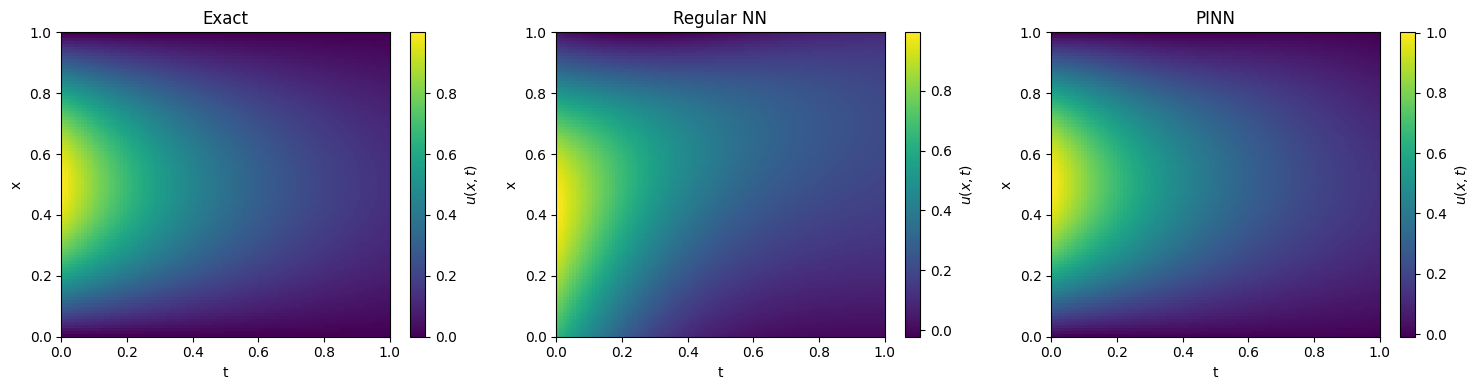

In [11]:
make_2d_hists(regular_NN, pinn, alpha=alpha)

## Use PyTorch to approximate the behaviour of the PINN

In [12]:
from symtorch import MLP_SR

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
num_data = 5000 # Create 5000 different data points
sample_data = torch.tensor(np.random.rand(num_data, 2), dtype=torch.float32) 
pinn.net = MLP_SR(pinn.net, 'pinn')

sr_params = {'niterations': 1000,
             'constraints': {'sin':3, 'exp':3}, 
             'complexity_of_operators': {'sin':3, 'exp':3},
             "unary_operators": ["inv(x) = 1/x", "sin", "exp"],
             'parsimony': 0.01,
             'nested_constraints':{'sin':{'sin':0, 'exp':0}, 'exp':{'exp':0, 'sin':0}},
             }

variable_names = ['x', 't']
fit_params = {'variable_names': variable_names}

In [14]:
pinn.net.distill(sample_data.to(torch.device('mps')), sr_params = sr_params,
                 fit_params=fit_params
                 )

/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


🛠️ Running SR on output dimension 0 of 0


[ Info: Started!



Expressions evaluated per second: 1.610e+05
Progress: 878 / 15500 total iterations (5.665%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.644e-02  0.000e+00  y = 0.27879
4           3.998e-02  4.994e-02  y = inv(t + 2.862)
5           2.541e-02  4.532e-01  y = (t * -0.50835) + 0.53178
6           2.416e-02  5.037e-02  y = inv(t + 0.94796) + -0.44186
8           2.409e-02  1.353e-03  y = inv(exp(t + t)) * 0.6401
9           1.348e-02  5.811e-01  y = (t + -2.0004) * (x * (x + -1.0493))
11          1.669e-03  1.044e+00  y = ((t * -0.8043) + 0.83983) * sin(x * 3.1217)
12          5.138e-05  3.481e+00  y = sin(x * 3.1228) * inv(exp(t + t))
14          3.337e-05  2.159e-01  y = sin(x * 3.1272) * (inv(exp(t + t)) + 0.0061439)
20          2.925e-05  2.194e-02  y = sin(x * 3.1272) * (i

[ Info: Final population:
[ Info: Results saved to:


{0: PySRRegressor.equations_ = [
 	    pick         score                                           equation  \
 	0         0.000000e+00                                         0.27878723   
 	1         4.993906e-02                                 inv(t + 2.8619585)   
 	2         4.532452e-01                      (t * -0.5083534) + 0.53178316   
 	3         5.040853e-02                     inv(t + 0.9438586) + -0.444103   
 	4         3.255343e-03                   exp(t * -1.9430747) * 0.63156635   
 	5         5.705574e-01                     x * (inv(x + t) + -0.46349502)   
 	6         1.459865e+00            (t + -0.93818444) * sin(x * -3.1513612)   
 	7         2.312822e+00           sin(x * 3.1266665) * exp(t * -1.9586251)   
 	8         5.811590e-07       inv(exp(t * 1.9585797)) * sin(x * 3.1266665)   
 	9         5.614046e-02  exp(t * -1.947756) * (sin(x * 3.1233711) + -0....   
 	10        1.431406e-01  sin(x * 3.1372416) * ((x * 0.023795936) + exp(...   
 	11        2.61382

  - SR_output/pinn/dim0_1755352947/hall_of_fame.csv
